# **PARTIE II du projet d'ALM**

In [ ]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## **Initilisation des parametres**

In [ ]:
ar      = 0.10
sigma_r = 0.0175

sigma_S = 0.20
rho     = 0.15

lambda1 = -0.205
lambda2 =  0.34

beta0, beta1, beta2, tau_NS = 0.0350, -0.0200, 0.0350, 4.00

Va_0   = 2_170_000_000.0
x_B    = 0.05
x_MF   = 0.15
x_bond = 0.80
T_bond = 4

s_M = 0.999441703848
g_M = 0.999733441115
c_M = 1.101077536030

# Profit-sharing
b_ps = 0.85
d_ps = 0.001

INSURANCE = [
    # (nb_pol, age, g_tech, Cl_0, T)
    (2500, 52, 0.005,   200_000, 13),
    (2250, 54, 0.005,   150_000, 11),
    (2000, 56, 0.010,   200_000,  9),
    (2200, 58, 0.0125,  130_000,  7),
    (1750, 60, 0.015,   125_000,  5),
    (2000, 62, 0.020,   100_000,  3),
    (2500, 64, 0.025,   100_000,  1),
]
N_MP = len(INSURANCE)

In [ ]:
def NS_rate(T, b0=beta0, b1=beta1, b2=beta2, tau=tau_NS):
    """Taux zéro-coupon continu (Nelson-Siegel)."""
    if T <= 1e-9:
        return b0 + b1
    x = T / tau
    ex = np.exp(-x)
    f  = (1 - ex) / x
    return b0 + b1 * f + b2 * (f - ex)

def P0T(T, b0=beta0, b1=beta1, b2=beta2, tau=tau_NS):
    """Prix ZC initial P(0,T)"""
    if T <= 1e-9:
        return 1.0
    return np.exp(-NS_rate(T, b0, b1, b2, tau) * T)

def f0T(T, eps=1e-5, **kw):
    return -(np.log(P0T(T + eps, **kw)) - np.log(P0T(max(T - eps, 1e-9), **kw))) / (2 * eps)

In [ ]:
def B_hw(t, T):
    return (1 - np.exp(-ar * (T - t))) / ar

def A_hw(t, T):
    if t < 1e-9:
        logP_ratio = np.log(P0T(T))
    else:
        logP_ratio = np.log(P0T(T)) - np.log(P0T(t))
    f = f0T(t)
    corr = (sigma_r**2 / (4 * ar)) * B_hw(t, T)**2 * (1 - np.exp(-2 * ar * t))
    return -logP_ratio + B_hw(t, T) * f - corr

def P_HW(t, T, x_t):
    return np.exp(-A_hw(t, T) - B_hw(t, T) * x_t)

def phi_t(t):
    return f0T(t) + (sigma_r**2 / (2 * ar**2)) * (1 - np.exp(-ar * t))**2

In [ ]:
print(B_hw(0,4))

3.2967995396436067


In [ ]:
def survival(age, T):
    return s_M**T * g_M**(c_M**age * (c_M**T - 1))

SURV = [survival(mp[1], mp[4]) for mp in INSURANCE]

In [ ]:
for mp in INSURANCE:
  print(mp)

(2500, 52, 0.005, 200000, 13)
(2250, 54, 0.005, 150000, 11)
(2000, 56, 0.01, 200000, 9)
(2200, 58, 0.0125, 130000, 7)
(1750, 60, 0.015, 125000, 5)
(2000, 62, 0.02, 100000, 3)
(2500, 64, 0.025, 100000, 1)


In [ ]:
def monte_carlo(x0=0.0, S0_norm=1.0, sigma_S_=None,
                seed=42, N_sim=10_000, avec_PS=True,shift_parallele=0.0):

    if sigma_S_ is None:
        sigma_S_ = sigma_S

    T_max = max(mp[4] for mp in INSURANCE)
    dt    = 1/12
    n_steps = T_max * 12

    rng = np.random.default_rng(seed)
    sqrt_dt = np.sqrt(dt)

    x  = np.full(N_sim, x0, dtype=float)
    Bt = np.ones(N_sim, dtype=float)
    S  = np.full(N_sim, S0_norm, dtype=float)
    Pt = np.full(N_sim, P0T(T_bond), dtype=float)

    Bt_prev = np.ones(N_sim, dtype=float)
    S_prev  = np.full(N_sim, S0_norm, dtype=float)
    Pt_prev = np.full(N_sim, P0T(T_bond), dtype=float)

    Va = np.full(N_sim, Va_0, dtype=float)
    Va_start_year = np.full(N_sim, Va_0, dtype=float)

    disc = np.ones(N_sim, dtype=float)
    Cl_curr = np.array([float(mp[3]) for mp in INSURANCE])
    Cl_mat  = np.tile(Cl_curr, (N_sim, 1))

    TP_sum = np.zeros(N_sim, dtype=float)
    x_paths = np.zeros((N_sim, n_steps + 1))
    S_paths = np.zeros((N_sim, n_steps + 1))
    x_paths[:, 0] = x
    S_paths[:, 0] = S

    current_year = 0

    for step in range(1, n_steps + 1):
        t_prev = (step - 1) * dt
        t_now  = step * dt

        Z1 = rng.standard_normal(N_sim)
        Z2 = rho * Z1 + np.sqrt(1 - rho**2) * rng.standard_normal(N_sim)

        x = x - ar * x * dt + sigma_r * sqrt_dt * Z1
        r_t = x + phi_t(t_now) + shift_parallele

        Bt = Bt_prev * np.exp(r_t * dt)

        S = S_prev * np.exp((r_t - 0.5 * sigma_S_**2) * dt + sigma_S_ * sqrt_dt * Z2)

        Pt = P_HW(t_now, t_now + T_bond, x)

        ret_B = Bt / Bt_prev - 1
        ret_S = S / S_prev - 1
        ret_P = Pt / Pt_prev - 1

        ret_Va = x_B * ret_B + x_MF * ret_S + x_bond * ret_P

        Va = Va * (1 + ret_Va)

        Bt_prev = Bt.copy()
        S_prev  = S.copy()
        Pt_prev = Pt.copy()

        disc = disc * np.exp(-r_t * dt)

        # Stocker
        x_paths[:, step] = x
        S_paths[:, step] = S

        if step % 12 == 0:
            current_year += 1
            year = current_year
            r_A = Va / Va_start_year - 1      # (N_sim,)
            Va_start_year = Va.copy()

            for j, (nb, age, g_tech, Cl0, T) in enumerate(INSURANCE):
                if year > T:
                    continue

                if avec_PS:
                    r_PS = np.minimum(
                        b_ps * np.maximum(r_A - d_ps - g_tech, 0.0),
                        0.03
                    )
                    Cl_mat[:, j] *= (1 + r_PS)
                else:
                    pass

                if year == T:
                    sp = SURV[j]
                    CF = nb * Cl_mat[:, j] * sp * disc
                    TP_sum += CF

    TP = TP_sum.mean()
    paths = {'x': x_paths, 'S': S_paths}

    return TP, paths

In [ ]:
def print_initial_term_structure():
    print("\n  Courbe Nelson-Siegel et B(0,T) :")
    print(f"  {'T':>4} | {'R(0,T)':>8} | {'P(0,T)':>8} | {'B(0,T)':>8} | {'f(0,T)':>8}")
    print("  " + "-"*48)
    for T in [1, 2, 3, 4, 5, 7, 10, 13, 15]:
        print(f"  {T:>4} | {NS_rate(T):>8.5f} | {P0T(T):>8.6f} | "
              f"{B_hw(0,T):>8.6f} | {f0T(T):>8.5f}")

In [ ]:
print_initial_term_structure()


  Courbe Nelson-Siegel et B(0,T) :
     T |   R(0,T) |   P(0,T) |   B(0,T) |   f(0,T)
  ------------------------------------------------
     1 |  0.02101 | 0.979205 | 0.951626 |  0.02624
     2 |  0.02558 | 0.950135 | 1.812692 |  0.03348
     3 |  0.02902 | 0.916623 | 2.591818 |  0.03795
     4 |  0.03161 | 0.881241 | 3.296800 |  0.04052
     5 |  0.03353 | 0.845632 | 3.934693 |  0.04180
     7 |  0.03600 | 0.777246 | 5.034147 |  0.04217
    10 |  0.03763 | 0.686365 | 6.321206 |  0.04054
    13 |  0.03808 | 0.609552 | 7.274682 |  0.03864
    15 |  0.03808 | 0.564823 | 7.768698 |  0.03762


## **QUESTION 2**

In [ ]:
def question2(seed=42, N_sim=10_000):
    print("\n" + "="*62)
    print("  QUESTION 2 — Valeur économique des TP")
    print("="*62)

    TP_PS,   paths = monte_carlo(seed=seed, N_sim=N_sim, avec_PS=True)
    TP_noPS, _     = monte_carlo(seed=seed, N_sim=N_sim, avec_PS=False)

    PS_val   = TP_PS - TP_noPS
    Eq_PS    = Va_0 - TP_PS
    Eq_noPS  = Va_0 - TP_noPS

    print(f"\n  TP avec profit-sharing  : {TP_PS:>22,.2f} euros")
    print(f"  TP sans profit-sharing  : {TP_noPS:>22,.2f} euros")
    print(f"  Valeur de l'option PS   : {PS_val:>22,.2f} euros")
    print(f"  Equity avec PS          : {Eq_PS:>22,.2f} euros")
    print(f"  Equity sans PS          : {Eq_noPS:>22,.2f} euros")
    print(f"\n  Analyse :")
    print(f"  si TP_PS > TP_noPS alors le PS augmente les engagements")
    print(f"    car l'assureur partage ses gains avec les assurés")
    print(f"  si Equity_noPS > Equity_PS alors sans PS le bilan est")
    print(f"    plus favorable pour l'actionnaire")

    return dict(TP_PS=TP_PS, TP_noPS=TP_noPS, PS_val=PS_val,
                Eq_PS=Eq_PS, Eq_noPS=Eq_noPS, paths=paths)

##  **QUESTION 3 — Duration numérique des TP**

In [ ]:
def question3(res2, seed=42, N_sim=10_000, h=0.0005):
    print("\n" + "="*62)
    print("  QUESTION 3 — Duration des TP (choc ±5bps sur x0)")
    print("="*62)

    TP_PS_up,   _ = monte_carlo(shift_parallele=+h, seed=seed, N_sim=N_sim, avec_PS=True)
    TP_PS_dn,   _ = monte_carlo(shift_parallele=-h, seed=seed, N_sim=N_sim, avec_PS=True)
    TP_noPS_up, _ = monte_carlo(shift_parallele=+h, seed=seed, N_sim=N_sim, avec_PS=False)
    TP_noPS_dn, _ = monte_carlo(shift_parallele=-h, seed=seed, N_sim=N_sim, avec_PS=False)

    D_PS   = -(TP_PS_up   - TP_PS_dn)   / (2 * h * res2['TP_PS'])
    D_noPS = -(TP_noPS_up - TP_noPS_dn) / (2 * h * res2['TP_noPS'])

    print(f"\n  h = {h} ({h*10000:.1f} bps)")
    print(f"  Duration TP avec PS    : {D_PS:.4f} ans")
    print(f"  Duration TP sans PS    : {D_noPS:.4f} ans")
    print(f"\n  Analyse :")
    print(f"  D_PS < D_noPS car le PS capte les gains")
    print(f"    quand les taux montent → réduit la sensibilité nette")
    print(f"  Comparaison Partie I (déterministe) : D ≈ 7.3 ans")

    return dict(D_PS=D_PS, D_noPS=D_noPS)

## **QUESTION 4 — Duration Gap (Equity Duration)**

In [ ]:
def duration_actif():
    return 0.8*T_bond

def question4(res2, res3):
    print("\n" + "="*62)
    print("  QUESTION 4 — Duration Gap et Impact")
    print("="*62)

    D_A    = duration_actif()
    D_PS   = res3['D_PS']
    D_noPS = res3['D_noPS']
    TP_PS  = res2['TP_PS']
    TP_noPS= res2['TP_noPS']

    S_0ps   = Va_0 - TP_PS
    S_0nops = Va_0 - TP_noPS

    D_gap_PS   = (Va_0 / S_0ps)   * D_A - D_PS   * (TP_PS / S_0ps)
    D_gap_noPS = (Va_0 / S_0nops) * D_A - D_noPS * (TP_noPS / S_0nops)

    print(f"\n  Duration actif D_A       : {D_A:.4f} ans")
    print(f"  Duration Equity avec PS  : {D_gap_PS:.4f} ans")
    print(f"  Duration Equity sans PS  : {D_gap_noPS:.4f} ans")

    dr = -0.002  # -20bps

    dS_PS   = -D_gap_PS   * S_0ps   * dr
    dS_noPS = -D_gap_noPS * S_0nops * dr

    print(f"\n  Impact delta_r =-20bps sur equity avec PS  : {dS_PS:>18,.0f} euros")
    print(f"  Impact delta_r =-20bps sur equity sans PS  : {dS_noPS:>18,.0f} euros")
    print(f"\n  Analyse :")
    print(f"  D_gap < 0 → passifs plus sensibles alors risque si taux baisse")
    print(f"  Le PS amplifie ce risque (D_gap_PS plus négatif)")

    return dict(D_A=D_A, D_gap_PS=D_gap_PS, D_gap_noPS=D_gap_noPS)

## **QUESTION 5 — Delta Explicite (analytique, sans PS)**

In [ ]:
def question5(res2):
    print("\n" + "="*62)
    print("  QUESTION 5 — Delta Explicite (Hull-White, sans PS)")
    print("="*62)

    Delta_Va = -x_bond * Va_0 * B_hw(0, T_bond)

    Delta_TP = 0.0
    print(f"\n  {'MP':>3} | {'B(0,T)':>8} | {'P(0,T)':>8} | {'Contribution':>16}")
    print("  " + "-"*42)
    for j, (nb, age, g_tech, Cl0, T) in enumerate(INSURANCE):
        sp   = SURV[j]
        bT   = B_hw(0, T)
        pT   = P0T(T)
        contrib = nb * Cl0 * sp * (-bT) * pT
        Delta_TP += contrib
        print(f"  {j+1:>3} | {bT:>8.4f} | {pT:>8.6f} | {contrib:>16,.2f}")

    Delta_S = Delta_Va - Delta_TP

    print(f"\n  Delta actifs   : {Delta_Va:>20,.2f} euros")
    print(f"  Delta TP noPS  : {Delta_TP:>20,.2f} euros")
    print(f"  Delta equity   : {Delta_S:>20,.2f} euros")
    print(f"\n  Interprétation : delta_equity = Delta_Va - Delta_TP")
    print(f"  Si x0 croit de 1 → equity change de {Delta_S:,.0f} euros")

    return dict(Delta_Va=Delta_Va, Delta_TP=Delta_TP, Delta_S=Delta_S)

## **QUESTION 6 — Delta Numérique (avec PS)**

In [ ]:
def question6(res5, seed=42, N_sim=10_000, h=1e-4):
    print("\n" + "="*62)
    print("  QUESTION 6 — Delta Numérique TP avec PS (±1bp sur x0)")
    print("="*62)

    TP_up, _ = monte_carlo(x0=+h, seed=seed, N_sim=N_sim, avec_PS=True)
    TP_dn, _ = monte_carlo(x0=-h, seed=seed, N_sim=N_sim, avec_PS=True)

    Delta_TP_PS = (TP_up - TP_dn) / (2 * h)
    Delta_Va    = res5['Delta_Va']
    Delta_S_PS  = Delta_Va - Delta_TP_PS

    print(f"\n  h = {h} ({h*10000:.1f} bps)")
    print(f"  TP(x0+h)              : {TP_up:>20,.2f} €")
    print(f"  TP(x0-h)              : {TP_dn:>20,.2f} €")
    print(f"  Delta TP avec PS      : {Delta_TP_PS:>20,.2f} €")
    print(f"  Delta actifs          : {Delta_Va:>20,.2f} €")
    print(f"  Delta equity avec PS  : {Delta_S_PS:>20,.2f} €")
    print(f"\n  Comparaison Delta_TP_PS vs Delta_TP_noPS :")
    print(f"  Delta_TP noPS  : {res5['Delta_TP']:>20,.2f} €")
    print(f"  Différence PS  : {Delta_TP_PS - res5['Delta_TP']:>20,.2f} euros")

    return dict(Delta_TP_PS=Delta_TP_PS, Delta_S_PS=Delta_S_PS,
                Delta_Va=Delta_Va)

## **QUESTION 7 — Nominal du Forward Start Swap**

In [ ]:
def swap_analytics(T0=5, Tn=10, tau=0.5):

    pay_dates = np.arange(T0 + tau, Tn + tau/2, tau)

    num   = P0T(T0) - P0T(Tn)
    denom = tau * sum(P0T(Ti) for Ti in pay_dates)
    K_star = num / denom

    D_CB = sum(K_star * tau * B_hw(0, Ti) * P0T(Ti) for Ti in pay_dates) \
           + B_hw(0, Tn) * P0T(Tn)

    D_FR = B_hw(0, T0) * P0T(T0)

    Delta_swap_unit = -(D_CB - D_FR)

    return K_star, Delta_swap_unit, D_CB, D_FR

def question7(res5, res6, T0=5, Tn=10):
    print("\n" + "="*62)
    print("  QUESTION 7 — Nominal Forward Start Swap (Delta Hedge)")
    print("="*62)

    tau = 0.5
    K_star, Dsu, D_CB, D_FR = swap_analytics(T0, Tn, tau)

    print(f"\n  T0={T0} ans, Tn={Tn} ans, paiements semestriels (tau={tau})")
    print(f"  Dates de paiement      : {np.arange(T0 + tau, Tn + tau/2, tau)}")
    print(f"  K_opt (forward swap rate) : {K_star*100:.4f}%")
    print(f"  delta_jambe fixe /N        : {D_CB:.6f}")
    print(f"  delta_jambe flottante /N   : {D_FR:.6f}")
    print(f"  delta_swap / N (unité)     : {Dsu:.6f}")

    # N* tel que Delta_equity + N * Delta_swap = 0
    N_noPS = -res5['Delta_S']  / Dsu
    N_PS   = -res6['Delta_S_PS'] / Dsu

    print(f"\n  Sans profit-sharing :")
    print(f"    Delta equity : {res5['Delta_S']:>18,.2f} €")
    print(f"    N* swap      : {N_noPS:>18,.2f} €")

    print(f"\n  Avec profit-sharing :")
    print(f"    Delta equity : {res6['Delta_S_PS']:>18,.2f} €")
    print(f"    N* swap      : {N_PS:>18,.2f} €")

    if N_noPS > 0:
        print(f"\n  Position : RECEIVER (recevoir fixe, payer flottant) ")
    else:
        print(f"\n  Position : PAYER (payer fixe, recevoir flottant)")

    return dict(K_star=K_star, N_noPS=N_noPS, N_PS=N_PS, Delta_swap_unit=Dsu)

## **QUESTION 8 — Delta / S0**

In [ ]:

def question8(res2, seed=42, N_sim=10_000):
    print("\n" + "="*62)
    print("  QUESTION 8 — Delta TP par rapport à S0")
    print("="*62)

    S0_base = 1.0
    h_S = 0.01 * S0_base   # choc 1%

    TP_up, _ = monte_carlo(S0_norm=S0_base + h_S, seed=seed, N_sim=N_sim, avec_PS=True)
    TP_dn, _ = monte_carlo(S0_norm=S0_base - h_S, seed=seed, N_sim=N_sim, avec_PS=True)

    Delta_TP_S0 = (TP_up - TP_dn) / (2 * h_S)

    Delta_Va_S0 = x_MF * Va_0

    Delta_PS_S0 = Delta_TP_S0

    Delta_S_S0 = Delta_Va_S0 - Delta_TP_S0

    print(f"\n  h_S = {h_S:.3f} ({h_S/S0_base*100:.0f}% de S0)")
    print(f"  TP(S0+h)              : {TP_up:>20,.2f} ")
    print(f"  TP(S0-h)              : {TP_dn:>20,.2f} ")
    print(f"  Delta TP / S0         : {Delta_TP_S0:>20,.2f} ")
    print(f"  Delta actifs / S0     : {Delta_Va_S0:>20,.2f} ")
    print(f"  Delta option PS / S0  : {Delta_PS_S0:>20,.2f} ")
    print(f"  Delta equity / S0     : {Delta_S_S0:>20,.2f} ")
    print(f"\n  Analyse :")
    print(f"  si Delta_TP_S0 > 0 alors si S0↑, le PS augmente")
    print(f"    les engagements alors TP augmente")
    return dict(Delta_TP_S0=Delta_TP_S0, Delta_Va_S0=Delta_Va_S0,
                Delta_PS_S0=Delta_PS_S0, Delta_S_S0=Delta_S_S0)


## **QUESTION 9**

In [ ]:

def question9(res2, seed=42, N_sim=10_000):
    print("\n" + "="*62)
    print("  QUESTION 9 — Vega (sensibilité à σ_S)")
    print("="*62)

    h_sig = 0.001

    TP_up, _ = monte_carlo(sigma_S_=sigma_S + h_sig, seed=seed, N_sim=N_sim, avec_PS=True)
    TP_dn, _ = monte_carlo(sigma_S_=sigma_S - h_sig, seed=seed, N_sim=N_sim, avec_PS=True)

    Vega_TP = (TP_up - TP_dn) / (2 * h_sig)
    Vega_Va = 0.0
    Vega_PS = Vega_TP
    Vega_S  = Vega_Va - Vega_TP

    print(f"\n  h_sigma = {h_sig} ({h_sig*100:.1f}%)")
    print(f"  TP(sigma+h)               : {TP_up:>20,.2f} euros")
    print(f"  TP(sigma-h)               : {TP_dn:>20,.2f} euros")
    print(f"  Vega TP (= Vega PS)   : {Vega_TP:>20,.2f} euros")
    print(f"  Vega equity           : {Vega_S:>20,.2f} euros")
    print(f"\n  Analyse :")
    print(f"  si Vega_TP > 0 : le PS est une option sur r_A")
    print(f"    alors plus de vol alors  plus de chance de PS élevé d'ou TP hausse")

    return dict(Vega_TP=Vega_TP, Vega_PS=Vega_PS, Vega_S=Vega_S)

## **QUESTION 10 — Distribution sous P (horizon 1 an)**

In [ ]:

def question10():
    print("\n" + "="*62)
    print("  QUESTION 10 — Distribution sous P (horizon 1 an)")
    print("="*62)

    T_hor = 1.0
    x0_hw = 0.0

    drift_adj = sigma_r * lambda1

    mu_x1  = x0_hw * np.exp(-ar * T_hor) \
             + (drift_adj / ar) * (1 - np.exp(-ar * T_hor))
    var_x1 = (sigma_r**2 / (2 * ar)) * (1 - np.exp(-2 * ar * T_hor))
    std_x1 = np.sqrt(var_x1)

    q10_x = norm.ppf(0.10, mu_x1, std_x1)
    q90_x = norm.ppf(0.90, mu_x1, std_x1)

    print(f"\n  --- Facteur de taux x_1 sous P ---")
    print(f"  Drift réel : -ar*x + sigma_r*|lambda1| = -0.1*x + {drift_adj:.5f}")
    print(f"  E[x_1]         : {mu_x1:.6f}")
    print(f"  Std[x_1]       : {std_x1:.6f}")
    print(f"  Quantile 10%   : {q10_x:.6f}")
    print(f"  Quantile 90%   : {q90_x:.6f}")

    r1_q10 = q10_x + phi_t(T_hor)
    r1_q90 = q90_x + phi_t(T_hor)
    print(f"\n  → Taux court r_1 = x_1 + phi(1) [φ(1)={phi_t(1):.4f}]")
    print(f"  Quantile 10% r_1 : {r1_q10:.4f}")
    print(f"  Quantile 90% r_1 : {r1_q90:.4f}")

    r0 = phi_t(0)
    mu_real = r0 + sigma_S * lambda2
    mu_log  = (mu_real - 0.5 * sigma_S**2) * T_hor
    sig_log = sigma_S * np.sqrt(T_hor)

    E_S1   = np.exp(mu_log + 0.5 * sig_log**2)
    Var_S1 = (np.exp(sig_log**2) - 1) * E_S1**2
    Std_S1 = np.sqrt(Var_S1)

    q10_S = np.exp(mu_log + norm.ppf(0.10) * sig_log)
    q90_S = np.exp(mu_log + norm.ppf(0.90) * sig_log)

    print(f"\n  --- Mutual Fund S_1 sous P (normalisé S_0=1) ---")
    print(f"  r0 initial NS  : {r0:.5f}")
    print(f"  lambda2        : {lambda2}")
    print(f"  Drift réel     : r_t + σ_S*λ2 ≈ {mu_real:.5f}")
    print(f"  μ(log S_1)     : {mu_log:.5f}")
    print(f"  σ(log S_1)     : {sig_log:.5f}")
    print(f"  E[S_1]         : {E_S1:.5f}  (rendement esp. {(E_S1-1)*100:.2f}%)")
    print(f"  Std[S_1]       : {Std_S1:.5f}")
    print(f"  Quantile 10%   : {q10_S:.5f}  ({(q10_S-1)*100:.2f}%)")
    print(f"  Quantile 90%   : {q90_S:.5f}  ({(q90_S-1)*100:.2f}%)")

    return dict(mu_x1=mu_x1, std_x1=std_x1, q10_x=q10_x, q90_x=q90_x,
                E_S1=E_S1, Std_S1=Std_S1, q10_S=q10_S, q90_S=q90_S)

In [ ]:
if __name__ == "__main__":
    SEED  = 42
    NSIM  = 100_000

    print("╔══════════════════════════════════════════════════════════╗")
    print("║  Modèle Stochastique — Questions 2 à 10     ║")
    print(f"║  N_sim = {NSIM:,} | seed = {SEED}                          ║")
    print("╚══════════════════════════════════════════════════════════╝")

    print_initial_term_structure()

    print("\n  Survies Makeham (vérification) :")
    for j, (nb, age, g, Cl, T) in enumerate(INSURANCE):
        print(f"  MP{j+1} age={age} T={T}: _T p_x = {SURV[j]:.6f}")

    r2  = question2(SEED, NSIM)
    r3  = question3(r2,  SEED, NSIM)
    r4  = question4(r2, r3)
    r5  = question5(r2)
    r6  = question6(r5, SEED, NSIM)
    r7  = question7(r5, r6)
    r8  = question8(r2, SEED, NSIM)
    r9  = question9(r2, SEED, NSIM)
    r10 = question10()

    print("\n" + "="*62)
    print("  SYNTHÈSE FINALE")
    print("="*62)
    print(f"  TP avec PS          : {r2['TP_PS']:>22,.0f} euros")
    print(f"  TP sans PS          : {r2['TP_noPS']:>22,.0f} euros")
    print(f"  Valeur option PS    : {r2['PS_val']:>22,.0f} euros")
    print(f"  D_gap avec PS       : {r4['D_gap_PS']:>22.4f} ans")
    print(f"  D_gap sans PS       : {r4['D_gap_noPS']:>22.4f} ans")
    print(f"  Delta equity noPS   : {r5['Delta_S']:>22,.0f} euros")
    print(f"  Delta equity avecPS : {r6['Delta_S_PS']:>22,.0f} euros")
    print(f"  K* swap             : {r7['K_star']*100:>22.4f}%")
    print(f"  N* swap (noPS)      : {r7['N_noPS']:>22,.0f} euros")
    print(f"  N* swap (avecPS)    : {r7['N_PS']:>22,.0f} euros")
    print(f"  Vega equity         : {r9['Vega_S']:>22,.0f} euros")
    print(f"  E[x_1] sous P       : {r10['mu_x1']:>22.5f}")
    print(f"  E[S_1] sous P       : {r10['E_S1']:>22.5f}")

╔══════════════════════════════════════════════════════════╗
║  Modèle Stochastique — Questions 2 à 10     ║
║  N_sim = 100,000 | seed = 42                          ║
╚══════════════════════════════════════════════════════════╝

  Courbe Nelson-Siegel et B(0,T) :
     T |   R(0,T) |   P(0,T) |   B(0,T) |   f(0,T)
  ------------------------------------------------
     1 |  0.02101 | 0.979205 | 0.951626 |  0.02624
     2 |  0.02558 | 0.950135 | 1.812692 |  0.03348
     3 |  0.02902 | 0.916623 | 2.591818 |  0.03795
     4 |  0.03161 | 0.881241 | 3.296800 |  0.04052
     5 |  0.03353 | 0.845632 | 3.934693 |  0.04180
     7 |  0.03600 | 0.777246 | 5.034147 |  0.04217
    10 |  0.03763 | 0.686365 | 6.321206 |  0.04054
    13 |  0.03808 | 0.609552 | 7.274682 |  0.03864
    15 |  0.03808 | 0.564823 | 7.768698 |  0.03762

  Survies Makeham (vérification) :
  MP1 age=52 T=13: _T p_x = 0.898764
  MP2 age=54 T=11: _T p_x = 0.907415
  MP3 age=56 T=9: _T p_x = 0.917797
  MP4 age=58 T=7: _T p_x = 0.

# **Question 11**


In [ ]:
S0_PS       = Va_0 - r2['TP_PS']
Delta_S     = r6['Delta_S_PS']
q10_x1      = r10['q10_x']
Delta_limit = 0.15 * S0_PS / abs(q10_x1)

In [ ]:
print(f"Equity avec PS          : {S0_PS:>20,.2f} €")
print(f"Quantile 10% x1 sous P  : {q10_x1:>20.6f}")
print(f"Delta equity actuel     : {Delta_S:>20,.2f} €")
print(f"Limite delta max        : {Delta_limit:>20,.2f} €")

if abs(Delta_S) <= Delta_limit:
    print("Dans les limites de risque")
else:
    print(f"Hors limites, réduction nécessaire : {abs(Delta_S) - Delta_limit:>,.2f} €")

Equity avec PS          :       535,060,929.11 €
Quantile 10% x1 sous P  :            -0.024765
Delta equity actuel     :     1,662,259,933.95 €
Limite delta max        :     3,240,815,736.91 €
Dans les limites de risque


## **Question 12**

In [ ]:
N_scen = 100_000
rng12  = np.random.default_rng(42)

x1_sim   = rng12.normal(r10['mu_x1'], r10['std_x1'], N_scen)
mu_log   = (phi_t(0) + sigma_S * lambda2 - 0.5 * sigma_S**2) * 1.0
sig_log  = sigma_S * np.sqrt(1.0)
S1_sim   = np.exp(rng12.normal(mu_log, sig_log, N_scen))

delta_x  = x1_sim - 0.0
delta_S  = S1_sim - 1.0

PnL = r6['Delta_S_PS'] * delta_x + r8['Delta_S_S0'] * delta_S

In [ ]:
mean_PnL  = PnL.mean()
std_PnL   = PnL.std()
p005_PnL  = np.percentile(PnL, 0.5)
p995_PnL  = np.percentile(PnL, 99.5)

print(f"Mean P&L      : {mean_PnL:>20,.2f} €")
print(f"Std P&L       : {std_PnL:>20,.2f} €")
print(f"Percentile 0.5%  : {p005_PnL:>20,.2f} €")
print(f"Percentile 99.5% : {p995_PnL:>20,.2f} €")

Mean P&L      :        19,957,998.69 €
Std P&L       :        76,416,914.22 €
Percentile 0.5%  :      -146,273,349.61 €
Percentile 99.5% :       256,929,798.15 €


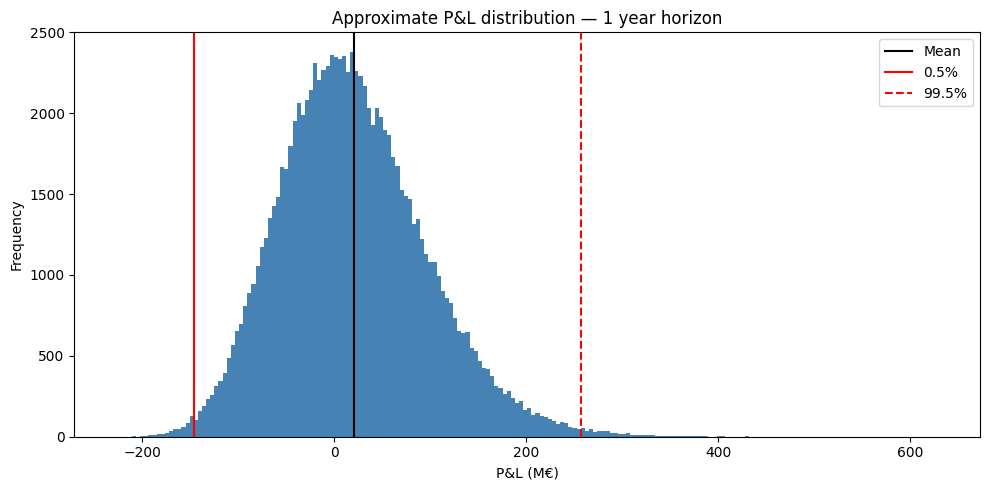

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(PnL / 1e6, bins=200, color='steelblue', edgecolor='none')
plt.axvline(mean_PnL / 1e6, color='black', linestyle='solid', label='Mean')
plt.axvline(p005_PnL / 1e6, color='red',   linestyle='solid', label='0.5%')
plt.axvline(p995_PnL / 1e6, color='red',   linestyle='dashed', label='99.5%')
plt.xlabel("P&L (M€)")
plt.ylabel("Frequency")
plt.title("Approximate P&L distribution — 1 year horizon")
plt.legend()
plt.tight_layout()
plt.show()

## **Question 13**

In [ ]:
S0_PS  = Va_0 - r2['TP_PS']
Eq_1   = S0_PS + PnL

mean_Eq  = Eq_1.mean()
std_Eq   = Eq_1.std()
p005_Eq  = np.percentile(Eq_1, 0.5)
p995_Eq  = np.percentile(Eq_1, 99.5)

print(f"Mean Equity      : {mean_Eq:>20,.2f} €")
print(f"Std Equity       : {std_Eq:>20,.2f} €")
print(f"Percentile 0.5%  : {p005_Eq:>20,.2f} €")
print(f"Percentile 99.5% : {p995_Eq:>20,.2f} €")

Mean Equity      :       555,018,927.80 €
Std Equity       :        76,416,914.22 €
Percentile 0.5%  :       388,787,579.50 €
Percentile 99.5% :       791,990,727.25 €


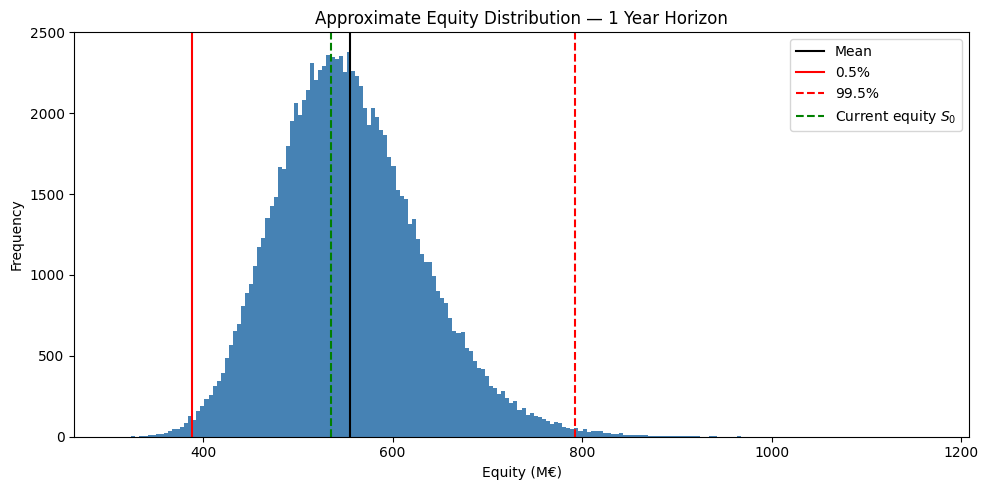

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(Eq_1 / 1e6, bins=200, color='steelblue', edgecolor='none')
plt.axvline(mean_Eq / 1e6, color='black',   linestyle='solid',  label='Mean')
plt.axvline(p005_Eq / 1e6, color='red',     linestyle='solid',  label='0.5%')
plt.axvline(p995_Eq / 1e6, color='red',     linestyle='dashed', label='99.5%')
plt.axvline(S0_PS   / 1e6, color='green',   linestyle='dashed', label='Current equity $S_0$')
plt.xlabel("Equity (M€)")
plt.ylabel("Frequency")
plt.title("Approximate Equity Distribution — 1 Year Horizon")
plt.legend()
plt.tight_layout()
plt.show()

## **Question 14**

In [ ]:
SCR             = S0_PS - p005_Eq
solvency_ratio  = S0_PS / SCR

print(f"Current Equity S0     : {S0_PS:>20,.2f} €")
print(f"0.5% Equity Percentile: {p005_Eq:>20,.2f} €")
print(f"SCR                   : {SCR:>20,.2f} €")
print(f"Solvency Ratio        : {solvency_ratio:>20.4f}")
print(f"Solvency Ratio (%)    : {solvency_ratio*100:>19.2f}%")

Current Equity S0     :       535,060,929.11 €
0.5% Equity Percentile:       388,787,579.50 €
SCR                   :       146,273,349.61 €
Solvency Ratio        :               3.6580
Solvency Ratio (%)    :              365.80%


## **Question 15**

In [ ]:
T_bond_new = 7

In [ ]:
def monte_carlo_q15(x0=0.0, S0_norm=1.0, sigma_S_=None,
                    seed=42, N_sim=10_000, avec_PS=True, shift_parallele=0.0):

    if sigma_S_ is None:
        sigma_S_ = sigma_S

    T_max    = max(mp[4] for mp in INSURANCE)
    dt       = 1/12
    n_steps  = T_max * 12
    rng      = np.random.default_rng(seed)
    sqrt_dt  = np.sqrt(dt)

    x       = np.full(N_sim, x0,          dtype=float)
    Bt      = np.ones(N_sim,              dtype=float)
    S       = np.full(N_sim, S0_norm,     dtype=float)
    Pt      = np.full(N_sim, P0T(T_bond_new), dtype=float)

    Bt_prev = np.ones(N_sim,              dtype=float)
    S_prev  = np.full(N_sim, S0_norm,     dtype=float)
    Pt_prev = np.full(N_sim, P0T(T_bond_new), dtype=float)

    Va            = np.full(N_sim, Va_0,  dtype=float)
    Va_start_year = np.full(N_sim, Va_0,  dtype=float)
    disc          = np.ones(N_sim,        dtype=float)
    Cl_mat        = np.tile([float(mp[3]) for mp in INSURANCE], (N_sim, 1))
    TP_sum        = np.zeros(N_sim,       dtype=float)
    current_year  = 0

    for step in range(1, n_steps + 1):
        t_now = step * dt

        Z1 = rng.standard_normal(N_sim)
        Z2 = rho * Z1 + np.sqrt(1 - rho**2) * rng.standard_normal(N_sim)

        x   = x - ar * x * dt + sigma_r * sqrt_dt * Z1
        r_t = x + phi_t(t_now) + shift_parallele

        Bt  = Bt_prev * np.exp(r_t * dt)
        S   = S_prev  * np.exp((r_t - 0.5 * sigma_S_**2) * dt + sigma_S_ * sqrt_dt * Z2)
        Pt  = P_HW(t_now, t_now + T_bond_new, x)

        ret_Va = x_B * (Bt/Bt_prev - 1) + x_MF * (S/S_prev - 1) + x_bond * (Pt/Pt_prev - 1)
        Va     = Va * (1 + ret_Va)

        Bt_prev = Bt.copy()
        S_prev  = S.copy()
        Pt_prev = Pt.copy()
        disc    = disc * np.exp(-r_t * dt)

        if step % 12 == 0:
            current_year += 1
            r_A           = Va / Va_start_year - 1
            Va_start_year = Va.copy()

            for j, (nb, age, g_tech, Cl0, T) in enumerate(INSURANCE):
                if current_year > T:
                    continue
                if avec_PS:
                    r_PS = np.minimum(b_ps * np.maximum(r_A - d_ps - g_tech, 0.0), 0.03)
                    Cl_mat[:, j] *= (1 + r_PS)
                if current_year == T:
                    TP_sum += nb * Cl_mat[:, j] * SURV[j] * disc

    return TP_sum.mean()

In [ ]:
TP_PS_new   = monte_carlo_q15(seed=42, N_sim=100_000, avec_PS=True)
TP_noPS_new = monte_carlo_q15(seed=42, N_sim=100_000, avec_PS=False)
S0_PS_new   = Va_0 - TP_PS_new

print(f"TP avec PS (nouveau)   : {TP_PS_new:>20,.2f} €")
print(f"Equity avec PS (nouveau): {S0_PS_new:>20,.2f} €")

TP avec PS (nouveau)   :     1,650,598,399.36 €
Equity avec PS (nouveau):       519,401,600.64 €


In [ ]:
h = 1e-4
TP_up_new = monte_carlo_q15(x0=+h, seed=42, N_sim=100_000, avec_PS=True)
TP_dn_new = monte_carlo_q15(x0=-h, seed=42, N_sim=100_000, avec_PS=True)

Delta_TP_PS_new  = (TP_up_new - TP_dn_new) / (2 * h)
Delta_Va_new     = -x_bond * Va_0 * B_hw(0, T_bond_new)
Delta_S_PS_new   = Delta_Va_new - Delta_TP_PS_new

h_S = 0.01
TP_up_S_new = monte_carlo_q15(S0_norm=1.0 + h_S, seed=42, N_sim=100_000, avec_PS=True)
TP_dn_S_new = monte_carlo_q15(S0_norm=1.0 - h_S, seed=42, N_sim=100_000, avec_PS=True)

Delta_TP_S0_new = (TP_up_S_new - TP_dn_S_new) / (2 * h_S)
Delta_Va_S0_new = x_MF * Va_0
Delta_S_S0_new  = Delta_Va_S0_new - Delta_TP_S0_new

print(f"Delta equity / x0 (nouveau) : {Delta_S_PS_new:>20,.2f} €")
print(f"Delta equity / S0 (nouveau) : {Delta_S_S0_new:>20,.2f} €")

Delta equity / x0 (nouveau) :    -1,227,251,509.92 €
Delta equity / S0 (nouveau) :       325,500,000.00 €


In [ ]:
PnL_new = Delta_S_PS_new * delta_x + Delta_S_S0_new * delta_S
Eq_1_new = S0_PS_new + PnL_new

SCR_new            = S0_PS_new - np.percentile(Eq_1_new, 0.5)
solvency_ratio_new = S0_PS_new / SCR_new

print(f"SCR (nouveau)             : {SCR_new:>20,.2f} €")
print(f"Solvency Ratio (nouveau)  : {solvency_ratio_new*100:>19.2f}%")
print(f"SCR (ancien)              : {SCR:>20,.2f} €")
print(f"Solvency Ratio (ancien)   : {solvency_ratio*100:>19.2f}%")

SCR (nouveau)             :       126,727,687.85 €
Solvency Ratio (nouveau)  :              409.86%
SCR (ancien)              :       146,273,349.61 €
Solvency Ratio (ancien)   :              365.80%
